1. In this Notebook I will going to perform efficient feature engineering on Essay Scoring dataset with the help of Polars and Regex.
2. Then I will going to perform Hypothesis Testing on some key selected columns and will present its effect size.
3. Then I will perform some Cluster Analysis with the help of Clustering Algorithms like KMeans, DBSCAN and OPTICS to see whether clusters can help us in splitting essays based on their score.
4. After that I will do perform predictive modelling with some Linear models, SVM and after that Multi Layer Perceptron.
5. Quadratic Weighted Kappa(QWK) aka Cohen Kappa will be used to evaluate created models.
6. Then I will try Thresholds optimization technique to see whether it can help us optimizing model's prediction even further.

In [1]:
# importing required libraries

import time
import pandas as pd
import polars as pl
import numpy as np
import regex as re
import string
from sklearn.feature_extraction.text import CountVectorizer #TfidfVectorizer,
from scipy.sparse import coo_matrix, hstack
import pickle
import lightgbm as lgbm
import warnings 
from scipy.stats import ttest_rel, ttest_ind, levene, shapiro, f_oneway, mannwhitneyu, kruskal, anderson
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Loading dataset
train = pl.read_csv("/kaggle/input/competitions/learning-agency-lab-automated-essay-scoring-2/train.csv")

In [3]:
train.head()

essay_id,full_text,score
str,str,i64
"""000d118""","""Many people have car where the…",3
"""000fe60""","""I am a scientist at NASA that …",3
"""001ab80""","""People always wish they had th…",4
"""001bdc0""","""We all heard about Venus, the …",4
"""002ba53""","""Dear, State Senator This is a…",3


In [4]:
# al contains all Correct words in a Set, which will be used for fiding Incorrect words

al = pickle.load(open("/kaggle/input/datasets/gursewak1/lgbm-v36/Correct_Words_Set/Correct_Words_Set.pkl", "rb"))

def remove__(x):
    """Removes multiple spaces"""
    return re.sub(r"\s{2,100000}", "", x) 


def return_len(x): 
    return len(x)


def clean_row_for_split(row):
    """Preprocessing required to split the words"""
    row = row.lower()
    row = re.sub(r"[\<\>\|\^\@\*²¹©\$\d\&,\/\.\(\)\[\]\&\%\#\!\-\_\=\+\:\?\"';]"," ", row)
    row = re.sub(r"\s{2,10000}", " ", row)
    row = row.split(" ")
    return row


def wordsAndError(x): 
    splitted = clean_row_for_split(x) 
    n = len(splitted)
    uni = Unique_words_prcnt(splitted)
    err = Spelling_Errors(splitted) 
    return (n, int(n * uni), uni, err)
    

def Spelling_Errors(row):
    """Returns spelling errors as percentage of total words"""
    num = 0
    nn = len(row)
    for tok in row:
        if tok not in al:
            num+=1

    return num/nn


def Unique_words_prcnt(row):
    """Returns Percentage of unique words"""
    return len(set(row))/len(row)

In [5]:
# Cleaning Full_text column which will be used to generate features

train = train.with_columns(pl.col("full_text").map_elements(remove__).alias("text_cln"))

pl_cols = [
    pl.col("text_cln").map_elements(return_len).alias("text_len"),
    pl.col("text_cln").map_elements(wordsAndError, return_dtype = pl.Object).alias("wordsUniError")
]

train = train.with_columns(pl_cols)

word_cols = [
    pl.col("wordsUniError").map_elements(lambda x: x[0], return_dtype = int).alias("total_words"), 
    pl.col("wordsUniError").map_elements(lambda x: x[1], return_dtype = int).alias("unique_words"), 
    pl.col("wordsUniError").map_elements(lambda x: x[2]*100, return_dtype = float).alias("unique_words%"), 
    pl.col("wordsUniError").map_elements(lambda x: x[3]*100, return_dtype = float).alias("error%"), 
]

train = train.with_columns(word_cols).drop("wordsUniError") 

In [6]:
def parasStats(x): 
    l = [] 
    for i in x: 
        l.append(len(i)) 
    return np.mean(l), np.median(l), np.max(l), np.min(l)

def getParasWordsStats(x):
    cnt, wrds, errPerc = [], [], []
    for para in x:
        s = wordsAndError(para)
        cnt.append(s[0])
        wrds.append(s[1])
        errPerc.append(s[3]) 
    
    return (
        np.mean(cnt), np.max(cnt), np.min(cnt),
        np.mean(wrds), np.max(wrds), np.min(wrds),
        np.mean(errPerc), np.max(errPerc), np.min(errPerc)
    )

In [7]:
# Creating list of paragraphs for an essay by splitting by `\n\n`
train = train.with_columns(pl.col("full_text").str.split("\n\n").alias("paragraphs"))
train = train.with_columns(pl.col("paragraphs").map_elements(lambda x: len(x), return_dtype = int).alias("total_paras"))

# paragrahp avg, min, max length
train = train.with_columns(pl.col("paragraphs").map_elements(parasStats, return_dtype = pl.Object).alias("paraStats"))

paraStatsCols = [
    pl.col("paraStats").map_elements(lambda x: x[0], return_dtype = float).alias("parasMeanLen"),
    pl.col("paraStats").map_elements(lambda x: x[1], return_dtype = float).alias("parasMedianLen"),
    pl.col("paraStats").map_elements(lambda x: x[2], return_dtype = float).alias("parasMaxLen"),
    pl.col("paraStats").map_elements(lambda x: x[3], return_dtype = float).alias("parasMinLen"),
]

train = train.with_columns(paraStatsCols)

# paragraph errors avg, min, max
train = train.with_columns(pl.col("paragraphs").map_elements(getParasWordsStats, return_dtype = pl.Object).alias("paraWordsStats"))

paraWordsStatsCols = [
    pl.col("paraWordsStats").map_elements(lambda x: x[0], return_dtype = float).alias("parasWordsCountMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[1], return_dtype = int).alias("parasWordsCountMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[2], return_dtype = int).alias("parasWordCountsMin"),

    pl.col("paraWordsStats").map_elements(lambda x: x[3], return_dtype = float).alias("parasUniWordsCountMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[4], return_dtype = int).alias("parasUniWordsCountMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[5], return_dtype = int).alias("parasUniWordsCountMin"),

    pl.col("paraWordsStats").map_elements(lambda x: x[6], return_dtype = float).alias("parasErrPercMean"), 
    pl.col("paraWordsStats").map_elements(lambda x: x[7], return_dtype = float).alias("parasErrPercMax"),
    pl.col("paraWordsStats").map_elements(lambda x: x[8], return_dtype = float).alias("parasErrPercMin"),
]

train = train.with_columns(paraWordsStatsCols).drop(["paraWordsStats", "paraStats", "paragraphs"])

In [8]:
# Remove everything from text other than alphabets
def PreprocessText(x):
    x = x.lower()
    x = re.sub(r"[0-9\&\,\.\_\~\+\-\(\)\*#\$\%@!\?:;`\|\"'\[\]\/\\]", " ", x)
    x = re.sub(r"[\s\.]{2,100000}", " ", x)
    return x

In [9]:
# Spitting essay into sentences by splitting the text by `.`

train = train.with_columns(pl.col("text_cln").str.split(".").alias("sentences"))

train = train.with_columns(pl.col("sentences").map_elements(lambda x: len(x), return_dtype = int).alias("total_sents"))

# Sentence avg, min, max length
train = train.with_columns(pl.col("sentences").map_elements(parasStats, return_dtype = pl.Object).alias("sentStats"))

paraStatsCols = [
    pl.col("sentStats").map_elements(lambda x: x[0], return_dtype = float).alias("sentMeanLen"),
    pl.col("sentStats").map_elements(lambda x: x[1], return_dtype = float).alias("sentMedianLen"),
    pl.col("sentStats").map_elements(lambda x: x[2], return_dtype = float).alias("sentMaxLen"),
    pl.col("sentStats").map_elements(lambda x: x[3], return_dtype = float).alias("sentMinLen"),
]

train = train.with_columns(paraStatsCols)

# Sentence errors avg, min, max word count
train = train.with_columns(pl.col("sentences").map_elements(getParasWordsStats, return_dtype = pl.Object).alias("sentWordsStats"))

paraWordsStatsCols = [
    pl.col("sentWordsStats").map_elements(lambda x: x[0], return_dtype = float).alias("sentWordsCountMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[1], return_dtype = int).alias("sentWordsCountMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[2], return_dtype = int).alias("sentWordCountsMin"),

    pl.col("sentWordsStats").map_elements(lambda x: x[3], return_dtype = float).alias("sentUniWordsCountMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[4], return_dtype = int).alias("sentUniWordsCountMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[5], return_dtype = int).alias("sentUniWordsCountMin"),

    pl.col("sentWordsStats").map_elements(lambda x: x[6], return_dtype = float).alias("sentErrPercMean"), 
    pl.col("sentWordsStats").map_elements(lambda x: x[7], return_dtype = float).alias("sentErrPercMax"),
    pl.col("sentWordsStats").map_elements(lambda x: x[8], return_dtype = float).alias("sentErrPercMin"),
]

train = train.with_columns(paraWordsStatsCols).drop(["sentWordsStats", "sentStats", "sentences"]) 

In [10]:
def getWordsOfLen(x): 
    """
    Takes list as argument 'x'
    returns count of words len greater than 1, 2, 3 and 4 
    and their percentages
    """
    a,b,c,d = 0,0,0,0 

    for w in x: 
        if len(w)>=4:
            a += 1
            b += 1 
            c += 1
            d += 1
        elif len(w)>=3:
            a += 1
            b += 1 
            c += 1
        elif len(w)>=2:
            a += 1
            b += 1 
        elif len(w)>=1:
            a += 1 

    return (a, b, c, d, a/len(x), b/len(x), c/len(x), d/len(x))

In [11]:
# Essay's Word Count and Percentage

train = train.with_columns(pl.col("text_cln").map_elements(clean_row_for_split, return_dtype = pl.Object).alias("words"))
train = train.with_columns(pl.col("words").map_elements(getWordsOfLen, pl.Object).alias("wordCounter")) 

wordCounterCols = [
    pl.col("wordCounter").map_elements(lambda x: x[0], return_dtype = int).alias("word>=1"),
    pl.col("wordCounter").map_elements(lambda x: x[1], return_dtype = int).alias("word>=2"),
    pl.col("wordCounter").map_elements(lambda x: x[2], return_dtype = int).alias("word>=3"),
    pl.col("wordCounter").map_elements(lambda x: x[3], return_dtype = int).alias("word>=4"),
    pl.col("wordCounter").map_elements(lambda x: x[4] * 100, return_dtype = float).alias("word>=1%"),
    pl.col("wordCounter").map_elements(lambda x: x[5] * 100, return_dtype = float).alias("word>=2%"),
    pl.col("wordCounter").map_elements(lambda x: x[6] * 100, return_dtype = float).alias("word>=3%"),
    pl.col("wordCounter").map_elements(lambda x: x[7] * 100, return_dtype = float).alias("word>=4%"),
]

train = train.with_columns(wordCounterCols).drop(["words", "wordCounter"]) 

In [12]:
# Reference to the Source text in an essay is referred by me as spans
# Here I am creating functions that will help in finding spans length, num and percentage of spans

def span_length(x, gap_width = 10):
    """
    Returns Sum  and Count of all the Source/Quoted text with length > gap width.
    NOTE, quoted text also contains quotes so their length always contains 2 more characters.
    Thats why, while returning I subtracted 2 from length. It is just to make more accurate 
    measurements.
    """
    
    num = 0
    cnt = 0
    for sp in x:
        gap = sp.span()[1] - sp.span()[0] 
        if gap > gap_width:
            num+= gap
            cnt+=1
        
    return num-(cnt*2), cnt

def find_span_length(x):
    """
    Find all the spans of double quoted text and pass it to `span_length` function
    to get total span length and number of spans.
    """
    
    spans = list(re.finditer(r"(?<=\")[^\"]{9,}(?=\")", x))
    return (span_length(spans))

train = train.with_columns(pl.col("text_cln").map_elements(find_span_length, return_dtype = pl.Object).alias("spans"))

spans_cols = [
    pl.col("spans").map_elements(lambda x: x[0], return_dtype = float).alias("spanLen"), 
    pl.col("spans").map_elements(lambda x: x[1], return_dtype = int).alias("spansCnt"), 
    pl.col("spans").map_elements(lambda x: 0 if x[1]==0 else (x[0]/x[1]), return_dtype = float).alias("LenPerSpan"), 
]

train = train.with_columns(spans_cols).drop("spans") 
train = train.with_columns(((pl.col("spanLen") / pl.col("text_len"))*100).alias("spans%"))
train.head()

essay_id,full_text,score,text_cln,text_len,total_words,unique_words,unique_words%,error%,total_paras,parasMeanLen,parasMedianLen,parasMaxLen,parasMinLen,parasWordsCountMean,parasWordsCountMax,parasWordCountsMin,parasUniWordsCountMean,parasUniWordsCountMax,parasUniWordsCountMin,parasErrPercMean,parasErrPercMax,parasErrPercMin,total_sents,sentMeanLen,sentMedianLen,sentMaxLen,sentMinLen,sentWordsCountMean,sentWordsCountMax,sentWordCountsMin,sentUniWordsCountMean,sentUniWordsCountMax,sentUniWordsCountMin,sentErrPercMean,sentErrPercMax,sentErrPercMin,word>=1,word>=2,word>=3,word>=4,word>=1%,word>=2%,word>=3%,word>=4%,spanLen,spansCnt,LenPerSpan,spans%
str,str,i64,str,i64,i64,i64,f64,f64,i64,f64,f64,f64,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64
"""000d118""","""Many people have car where the…",3,"""Many people have car where the…",2673,499,225,45.09018,3.607214,1,2677.0,2677.0,2677.0,2677.0,499.0,499,499,225.0,225,225,0.036072,0.036072,0.036072,14,190.0,158.0,595.0,0.0,36.571429,129,1,27.642857,72,1,0.13404,1.0,0.0,498,474,397,284,99.799599,94.98998,79.559118,56.913828,1703.0,6,283.833333,63.711186
"""000fe60""","""I am a scientist at NASA that …",3,"""I am a scientist at NASA that …",1661,337,147,43.620178,1.48368,5,332.2,343.0,501.0,184.0,68.2,100,38,47.0,63,30,0.031221,0.052632,0.01,20,82.1,65.0,250.0,0.0,17.6,50,1,15.55,38,1,0.200025,1.0,0.0,336,311,241,175,99.703264,92.284866,71.513353,51.928783,1377.0,3,459.0,82.901866
"""001ab80""","""People always wish they had th…",4,"""People always wish they had th…",3062,555,229,41.261261,0.900901,4,767.75,751.5,1083.0,485.0,139.5,204,86,85.75,113,61,0.016915,0.034884,0.004902,25,121.52,137.0,237.0,0.0,23.08,48,1,20.8,40,1,0.092708,1.0,0.0,554,540,445,317,99.81982,97.297297,80.18018,57.117117,746.0,5,149.2,24.363161
"""001bdc0""","""We all heard about Venus, the …",4,"""We all heard about Venus, the …",2693,449,217,48.329621,1.113586,5,538.6,399.0,983.0,129.0,90.8,166,26,65.2,105,24,0.023532,0.038462,0.014493,24,111.25,95.0,398.0,0.0,19.458333,63,1,17.458333,51,1,0.215412,1.0,0.0,448,432,351,277,99.777283,96.213808,78.173719,61.69265,1567.0,3,522.333333,58.187895
"""002ba53""","""Dear, State Senator This is a…",3,"""Dear, State SenatorThis is a l…",2184,378,140,37.037037,2.380952,6,366.333333,447.5,696.0,19.0,64.166667,119,3,39.833333,78,3,0.060469,0.25,0.0,16,135.5625,120.5,440.0,17.0,24.3125,77,3,19.9375,51,3,0.05466,0.166667,0.0,378,356,279,211,100.0,94.179894,73.809524,55.820106,50.0,1,50.0,2.289377


#### Following Columns will go through Hypothesis testing to very their statistical signficance

In [13]:
totalWords = "total_words"
textLen = "text_len"
uniqueWords = "unique_words"

errors = "error%"
parasErrosPerc = "parasErrPercMean"

spansLen = 'spanLen'
spansCount = 'spansCnt'
lenPerSpan = 'LenPerSpan'
spansPerc = 'spans%' 

parasWordsCountMean = 'parasWordsCountMean'
parasWordsCountMax = 'parasWordsCountMax'
parasWordCountsMin = 'parasWordCountsMin'

parasUniWordsCountMean = 'parasUniWordsCountMean'
parasUniWordsCountMax = 'parasUniWordsCountMax'
parasUniWordsCountMin = 'parasUniWordsCountMin'

binned_cols = [
    totalWords,
    textLen,
    uniqueWords,
    errors,
    parasErrosPerc,
    spansLen,
    spansCount,
    lenPerSpan,
    spansPerc,
    parasWordsCountMean,
    parasWordsCountMax,
    parasWordCountsMin,
    parasUniWordsCountMean,
    parasUniWordsCountMax,
    parasUniWordsCountMin,
]

#### I will create Histplot of selected columns, which then will use to get bins range

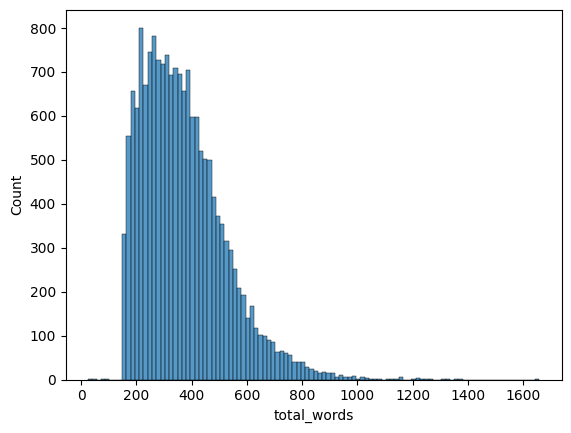

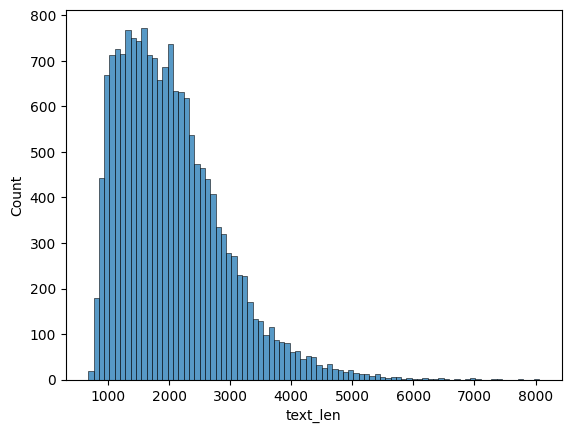

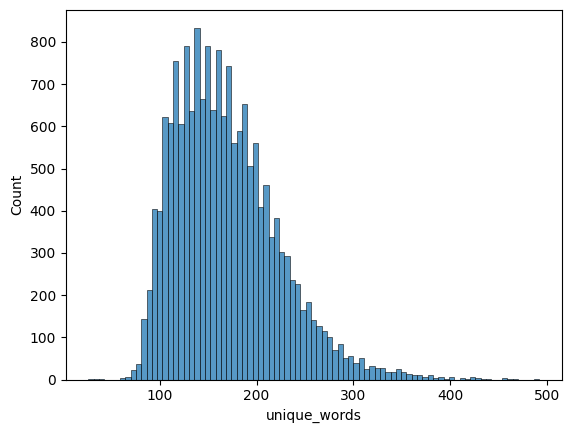

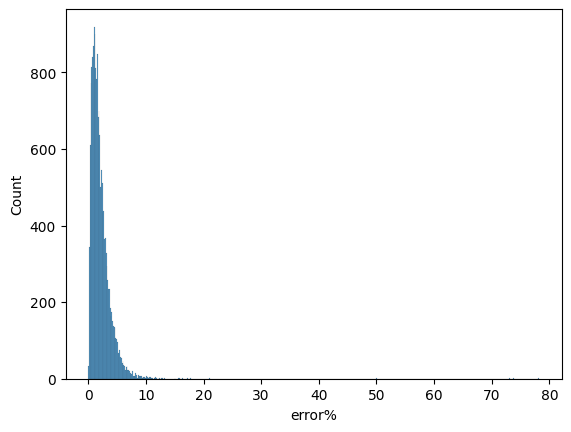

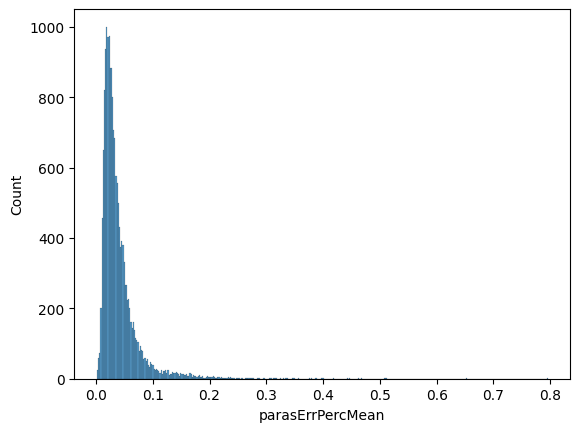

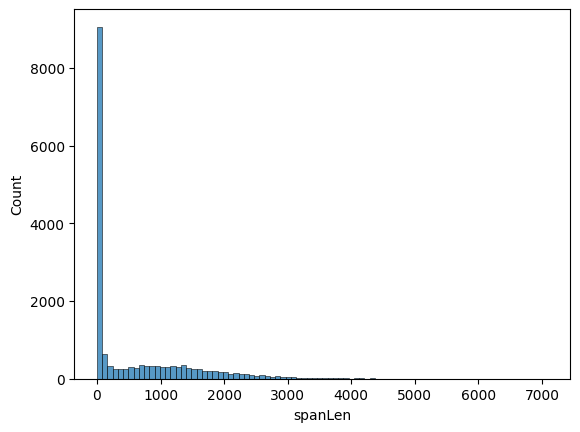

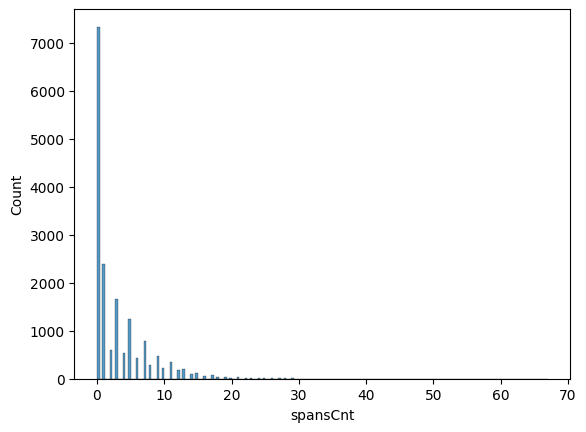

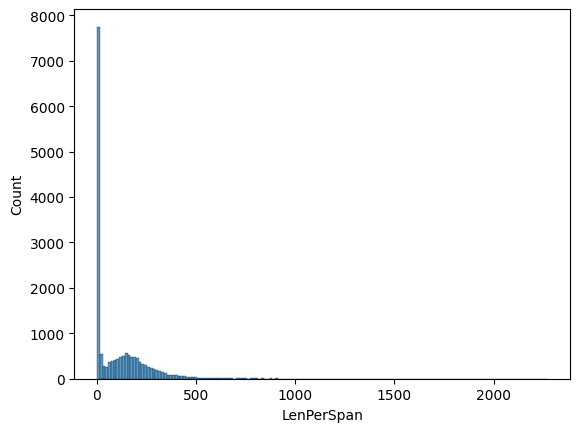

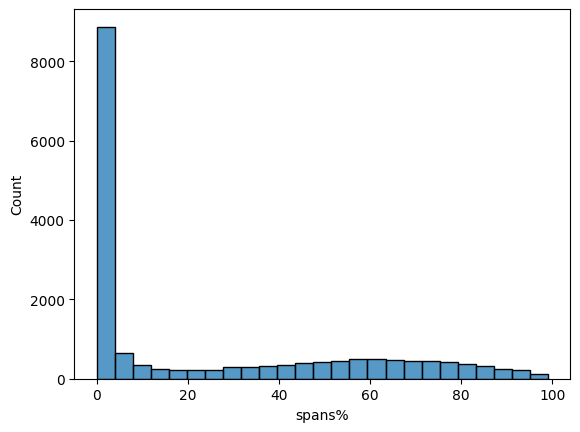

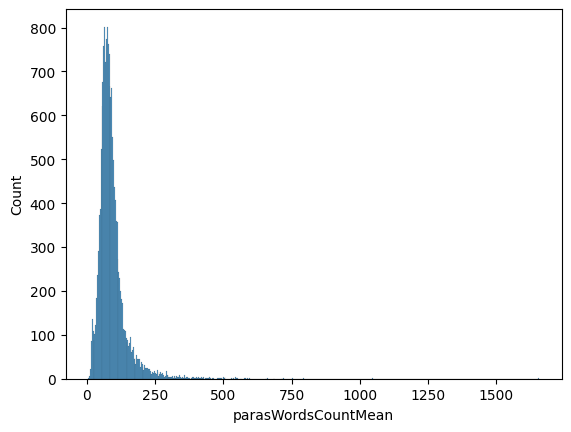

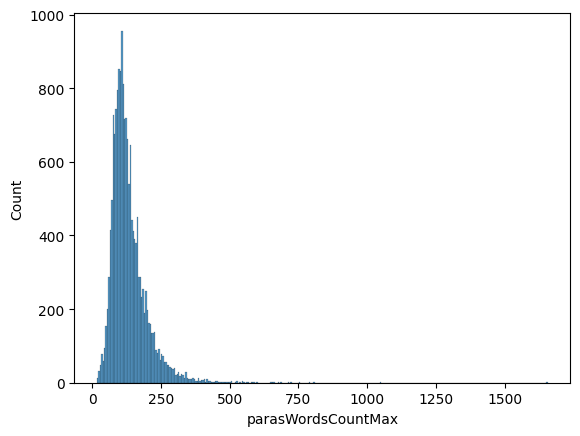

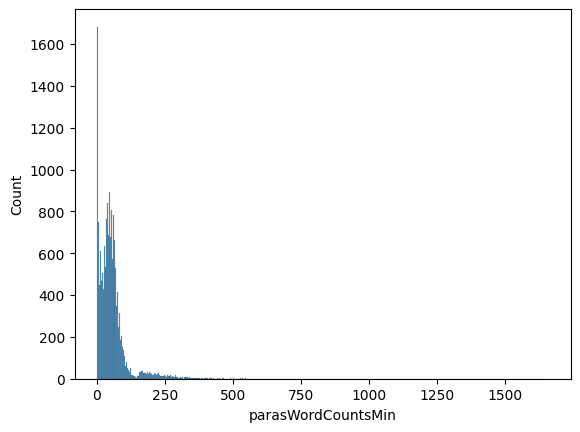

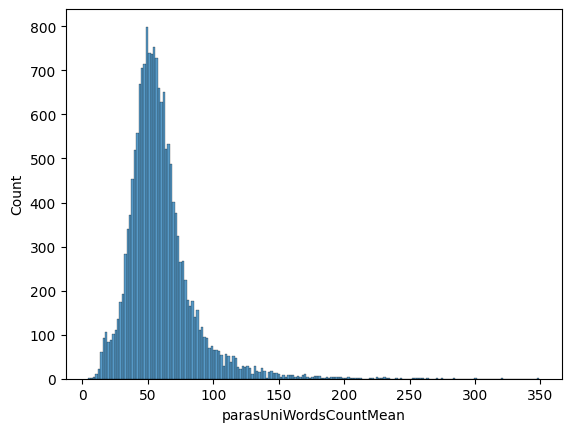

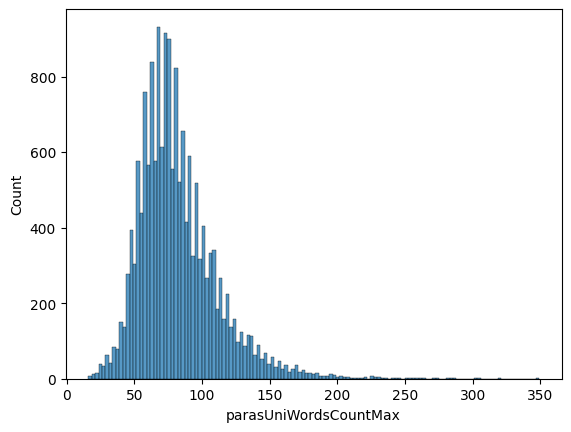

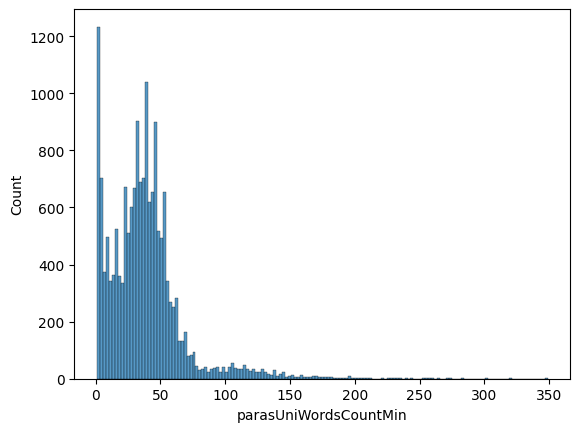

In [14]:
for col in binned_cols:
    sns.histplot(data=train, x = col)
    plt.show()

In [15]:
bins = {
    totalWords             : [200, 400, 600, 800],
    textLen                : [1000, 1800, 2600, 3400],
    uniqueWords            : [100, 150, 200, 250],
    errors                 : [2, 4, 6, 8],
    parasErrosPerc         : [.025, .05, .075, .1],
    spansLen               : [0, 800, 1600, 2400],
    spansCount             : [0, 4, 8, 13],
    lenPerSpan             : [0, 140, 280, 420],
    spansPerc              : [0, 25, 50, 75],
    parasWordsCountMean    : [60, 120, 180, 240],
    parasWordsCountMax     : [60, 120, 180, 240],
    parasWordCountsMin     : [10, 50, 100, 150],
    parasUniWordsCountMean : [25, 50, 75, 100],
    parasUniWordsCountMax  : [40, 80, 120, 160],
    parasUniWordsCountMin  : [10, 35, 60, 85]
}

In [16]:
def getGroupsList(data, col, count=5):
    """
    returns list of records of `count` groups of `col` column of `data` dataframe
    """
    grps = []
    for i in range(count):
        grps.append(data.filter(pl.col(col) == i)["score"])
    return grps

In [17]:
# Statistical Tests and their functions

def andersonTest(data):
    results = anderson(data.to_numpy(), dist="norm")
    if results.statistic <= results.critical_values[2]:
        return True, results
    return False, results

def shapiroTest(data):
    results = shapiro(data)
    if results.pvalue > .05:
        return True, results
    return False, results 

def leveneTest(data, col, count):
    grps = getGroupsList(data, col, count=count)
    return levene(*grps)

def kruskalWallisTest(data, col, count):
    grps = getGroupsList(data, col, count=count)
    return kruskal(*grps) 

def anovaTest(data, col, var, count):
    grps = getGroupsList(data, col, count=count)
    return f_oneway(*grps, equal_var = var)

In [18]:
def getBins(df, col, LIST):
    """
    returns dataframe that has new column 'col'_BINNED that has groups based upon `LIST` values
    """
    
    assert len(LIST)==4, f"Length of List should be 4, but given list length is {len(LIST)}"

    def inner(x, vals = LIST):
        if x<=LIST[0]: return 0
        elif x<=LIST[1]: return 1
        elif x<=LIST[2]: return 2
        elif x<=LIST[3]: return 3
        else: return 4

    df = df.with_columns(pl.col(col).map_elements(inner, return_dtype = int).alias(f"{col}_BINNED"))
    return df

In [19]:
# Some utility functions for Printing Texts

def getColoredText(x, r=255, g=0, b=0):
    txt = f"\33[38;2;{r};{g};{b}m{x}\33[m"
    return txt


def printChar(char = "*", n=100):
    print(char*n)


def defineHypothesisText(col, target="score", count=5):
    print(f"H0: All {5} groups of `{getColoredText(col, 255,255,)}` are not statistically significant as they possess same mean `{target}`.")
    print()
    print(f"H1: There is atleast one group in {getColoredText(col, 255,255)} whose mean `{target}` is statistically significant from all other groups.")
    printChar()


def defineHypothesisResultText(col, results):
    isSignificant = results.pvalue<.05
 
    if isSignificant:
        print(f"Groups of {col} are {getColoredText('STATISTICALLY SIGNIFICANT', 0, 255)} with P value {results.pvalue:.4f}, thus H0 is rejected.")
    else:
        print(f"Groups of {col} are not {getColoredText('STATISTICALLY SIGNIFICANT',)} with P value {results.pvalue:.4f}, thus H0 is not rejected.")
    printChar()
    return isSignificant


def testText(grp, cnt, flag, norm):
    if norm:
        normText = getColoredText("NORMAL", 0, 255,)
    else: 
        normText = getColoredText("NOT NORMAL")
        
    if flag: 
        print(f"On group {grp}({cnt}), We will use {getColoredText('Shapiro')} test, Found out it's {normText}")
    else: 
        print(f"On group {grp}({cnt}), We will use {getColoredText('Anderson-Darling', 0, 255, 0)} test, Found out it's {normText}")


_ = getColoredText("Demo")
print(getColoredText("This text will be Colored"))

This text will be Colored


In [20]:
# All selected columns will be binned into new columns

for col in bins.keys():
    train = getBins(train, col, bins[col])

In [21]:
def getGrpsCount(data, col):
    """
    Does mean of each group of column `col` of dataframe `data and
    Returns them as numpy array
    """
    return data.group_by([col]).agg(pl.col("score").count()).to_numpy()

In [22]:
def runNormalityTestOnGroups(data, col):
    grpsCount = getGrpsCount(data, col)
    NORMALS = 0
    results = {}
    
    for x in range(grpsCount.shape[0]):
        grp, cnt = grpsCount[x][0], grpsCount[x][1]
        flag = cnt<=5000
        
        if flag:
            normal, result = shapiroTest(data.filter(pl.col(col)==grp)["score"])
        else:
            normal, result = andersonTest(data.filter(pl.col(col)==grp)["score"])

        testText(grp, cnt, flag, normal)
        NORMALS += normal
        results[grp] = result
    printChar()

    return NORMALS == 5, results

In [23]:
def runVarianceTestOnGroups(data, col, count=5):
    print("Running Levene's test for homogeneity of Variance")
    printChar()
    results = leveneTest(data, col,count=count)
    variance = results.pvalue>.05
    printChar()
    if variance:
        print(f"Groups have {getColoredText('EQUAL VARIANCE', 0, 255)}, with P value {results.pvalue:.2f}")
    else:
        print(f"Groups have {getColoredText('UNEQUAL VARIANCE',)}, with P value {resuls.pvalue:.3f}")
    printChar()
        
    return variance, results

def runAnovaTestOnGroups(data, col, var=True, count=5):
    if var:
        print(f"Running {getColoredText('Standard ANOVA',)} test to check for statistical significance among groups")
    else: 
        print(f"Running {getColoredText('Welch ANOVA',)} test to check for statistical significance among groups")
    printChar()
    results = anovaTest(data, col, var, count=count)
    printChar()
    isSignificant = defineHypothesisResultText(col, results)
    printChar()
    return isSignificant, results

def runKruskalWallisTestOnGroups(data, col, count=5):
    print(f"Running {getColoredText('Kruskal Wallis', 0, 255)} test to check for statistical significance among groups")
    
    results = kruskalWallisTest(data, col,count=5)
    printChar()
    isSignificant = defineHypothesisResultText(col, results)
    printChar()
    return isSignificant, results

In [24]:
def runStatisticalTestOnGroups(data, col, target="score", count=5):
    """
    This functions will perform Hypothesis test on column `col`
    of dataframe `data` with group count `count`for mean of column `target` 
    Returns bool (statistical significance), TestResult
    """
    
    defineHypothesisText(col)
    n = 100
    isNormal, normResults = runNormalityTestOnGroups(train, col)

    if isNormal:

        print(f"All groups {col} are {getColoredText('NORMAL', 0, 255)}")
        printChar()
        
        isHomogeneous, varResults = runVarianceTestOnGroups(data, col )
        isSignificant, statsResults = runAnovaTestOnGroups(data, col, var=isHomogeneous, count=count)

    else:
        print(f"All groups of {col} are not {getColoredText('NOT NORMAL')}")
        printChar()
        isSignificant, statsResult = runKruskalWallisTestOnGroups(data, col, count=count) 

    return isSignificant, statsResult

In [25]:
# Calculating Cohen's Effect size (Both ETA and OMEGA Squared)

length = len(train)
grand_mean = train["score"].mean()
SST = np.sum((train["score"]-grand_mean).to_numpy()**2)

def getOmegaSquared(SSB, SST=SST,length=length, count=5):
    # Omega squared ω² for unequal grp size 
    df_between = count - 1
    df_within = length - count
    ms_within = (SST - SSB) / df_within

    return (SSB - (df_between * ms_within)) / (SST + ms_within)

def getEffect(value):
    if value <.01: return "No Effect"
    if value < .06: return "SMALL EFFECT"
    elif value < .14: return "MEDIUM EFFECT" 
    else: return "LARGE EFFECT" # .14

def getEffectSize(data, col, SST=SST, grand_mean = grand_mean, count=5 ):
    grps = getGroupsList(data, col)

    # Sum of Squared Between (SSB)
    SSB = 0
    for grp in grps:
        SSB += (len(grp) * (grp.mean() - grand_mean)**2)

    # ETA squared, (η²)
    eta_squared = SSB / SST 
    omega_squared = getOmegaSquared(SSB)
    
    return eta_squared, getEffect(eta_squared), omega_squared, getEffect(omega_squared)

In [26]:
statisticalDict = {}

for col in bins.keys():
    
    statisticalDict[f"{col}_Significance"], statisticalDict[f"{col}_Result"] = runStatisticalTestOnGroups(train, f"{col}_BINNED", target="score", count=5)
    eta, etaEffect, omega, omegaEffect = getEffectSize(train, f"{col}_BINNED",)
    print(f"Cohen's Effect Size (Omega Squared): {getColoredText(f"{omega:.2f}", 0, 255)}, {getColoredText(omegaEffect, 0, 255)}")
    print()
    printChar(char="_")

H0: All 5 groups of `total_words_BINNED` are not statistically significant as they possess same mean `score`.

H1: There is atleast one group in total_words_BINNED whose mean `score` is statistically significant from all other groups.
****************************************************************************************************
On group 0(1729), We will use Shapiro test, Found out it's NOT NORMAL
On group 3(1083), We will use Shapiro test, Found out it's NOT NORMAL
On group 4(238), We will use Shapiro test, Found out it's NOT NORMAL
On group 1(9284), We will use Anderson-Darling test, Found out it's NOT NORMAL
On group 2(4973), We will use Shapiro test, Found out it's NOT NORMAL
****************************************************************************************************
All groups of total_words_BINNED are not NOT NORMAL
****************************************************************************************************
Running Kruskal Wallis test to check for statistical

In [27]:
statisticalDict

{'total_words_Significance': np.True_,
 'total_words_Result': KruskalResult(statistic=np.float64(7256.100633043384), pvalue=np.float64(0.0)),
 'text_len_Significance': np.True_,
 'text_len_Result': KruskalResult(statistic=np.float64(8152.377316043948), pvalue=np.float64(0.0)),
 'unique_words_Significance': np.True_,
 'unique_words_Result': KruskalResult(statistic=np.float64(6612.394358465757), pvalue=np.float64(0.0)),
 'error%_Significance': np.True_,
 'error%_Result': KruskalResult(statistic=np.float64(1327.7607431581089), pvalue=np.float64(3.1853817780290163e-286)),
 'parasErrPercMean_Significance': np.True_,
 'parasErrPercMean_Result': KruskalResult(statistic=np.float64(967.5138830558757), pvalue=np.float64(3.913395567263435e-208)),
 'spanLen_Significance': np.True_,
 'spanLen_Result': KruskalResult(statistic=np.float64(3061.7953364377995), pvalue=np.float64(0.0)),
 'spansCnt_Significance': np.True_,
 'spansCnt_Result': KruskalResult(statistic=np.float64(1918.4310723809888), pvalue=

In [28]:
# Dropping following columns as they are not needed anymore

to_drop = ['essay_id','full_text','text_cln',]
train = train.drop(to_drop)

In [29]:
NumLabels = train["score"].unique().count()
Labels = train["score"]
NumLabels

6

#### Clustring with KMeans and other UnSupervised Learning Approaches

1. Here my motive was to find clusters with KMeans, DBSCAN, OPTICS to find out whether some clusters differ or not based on Essay Score

In [30]:
from sklearn.cluster import KMeans, DBSCAN, OPTICS

In [31]:
kmeans = KMeans(n_clusters = NumLabels, random_state = 42)
kmeans.fit(train.drop("score"))

KMeans(n_clusters=6, random_state=42)

In [32]:
kmeans.labels_

array([3, 2, 4, ..., 0, 3, 0], dtype=int32)

In [33]:
train = train.with_columns(pl.Series(kmeans.predict(train.drop("score"))).alias("CLUSTER_KMeans"))

In [34]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: xlabel='score', ylabel='Count'>

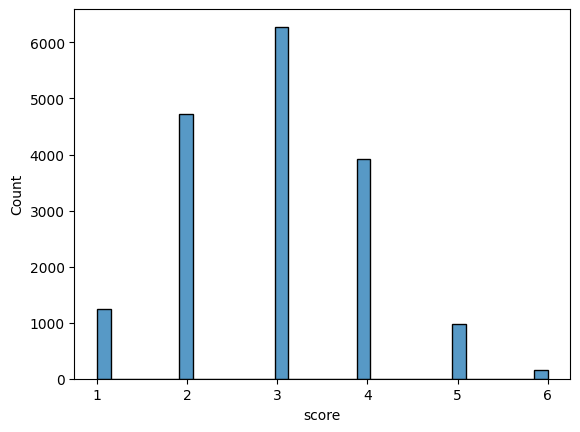

In [35]:
sns.histplot(data = train, x = "score")

<Axes: xlabel='CLUSTER_KMeans', ylabel='Count'>

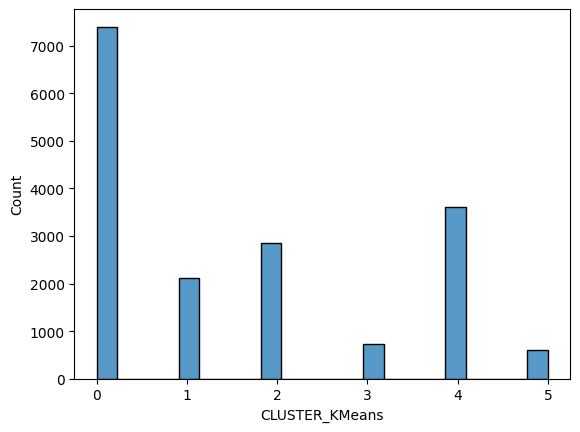

In [36]:
sns.histplot(data = train, x = "CLUSTER_KMeans")

In [37]:
train.group_by(pl.col("CLUSTER_KMeans")).agg([
    pl.col("score").count().alias("count"),
    pl.col("score").mean().alias("mean"), 
    pl.col("score").median().alias("median"), 
    pl.col("score").min().alias("min"), 
    pl.col("score").max().alias("max"), 
])

CLUSTER_KMeans,count,mean,median,min,max
i32,u32,f64,f64,i64,i64
0,7397,2.34879,2.0,1,4
3,736,2.014946,2.0,1,5
4,3599,3.485413,4.0,1,6
1,2114,3.856197,4.0,1,6
2,2852,3.035414,3.0,1,5
5,609,4.627258,5.0,1,6


In [38]:
col = "CLUSTER_KMeans"
statisticalDict[f"{col}_Significance"], statisticalDict[f"{col}_Result"] = runStatisticalTestOnGroups(train, col, target="score", count=NumLabels)
eta, etaEffect, omega, omegaEffect = getEffectSize(train, col,)
print(f"Cohen's Effect Size (Omega Squared): {getColoredText(f"{omega:.2f}", 0, 255)}, {getColoredText(omegaEffect, 0, 255)}")
print()
printChar(char="_")

H0: All 5 groups of `CLUSTER_KMeans` are not statistically significant as they possess same mean `score`.

H1: There is atleast one group in CLUSTER_KMeans whose mean `score` is statistically significant from all other groups.
****************************************************************************************************
On group 0(7397), We will use Anderson-Darling test, Found out it's NOT NORMAL
On group 3(736), We will use Shapiro test, Found out it's NOT NORMAL
On group 4(3599), We will use Shapiro test, Found out it's NOT NORMAL
On group 1(2114), We will use Shapiro test, Found out it's NOT NORMAL
On group 2(2852), We will use Shapiro test, Found out it's NOT NORMAL
On group 5(609), We will use Shapiro test, Found out it's NOT NORMAL
****************************************************************************************************
All groups of CLUSTER_KMeans are not NOT NORMAL
************************************************************************************************

<Axes: xlabel='CLUSTER_KMeans', ylabel='Count'>

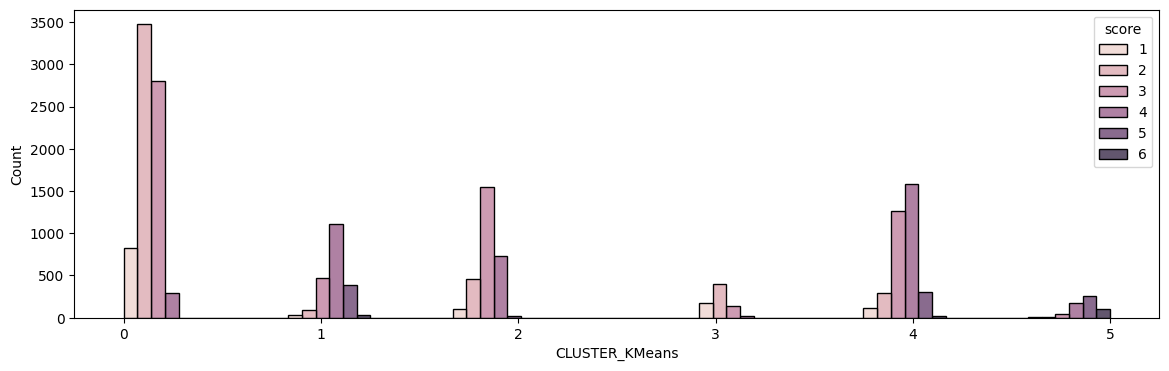

In [39]:
plt.figure(figsize = (14, 4))
sns.histplot(data = train, x = "CLUSTER_KMeans", hue = "score", multiple = "dodge", binwidth = .4)

In [40]:
dbscan = DBSCAN(eps = 5) 
dbscan.fit(train.drop(["CLUSTER_KMeans", "score"]))

DBSCAN(eps=5)

In [41]:
set(dbscan.labels_)

{np.int64(-1)}

In [42]:
dbscan.fit_predict(train.drop(["CLUSTER_KMeans", "score"]))

array([-1, -1, -1, ..., -1, -1, -1])

In [43]:
optics = OPTICS(min_samples = 17) 
optics.fit(train.drop(["CLUSTER_KMeans", "score"])) 

OPTICS(min_samples=17)

In [44]:
set(optics.labels_)

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)}

In [45]:
train = train.with_columns(pl.Series(optics.fit_predict(train.drop(["CLUSTER_KMeans", "score"]))).alias("OPTICS")) 

<Axes: xlabel='OPTICS', ylabel='Count'>

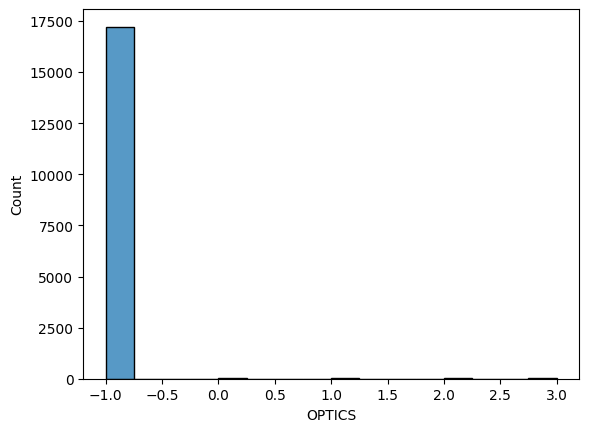

In [46]:
sns.histplot(data = train, x = "OPTICS")

In [47]:
train.group_by(pl.col("OPTICS")).agg([
    pl.col("score").count().alias("count"), 
    pl.col("score").mean().alias("mean"), 
    pl.col("score").median().alias("median"), 
    pl.col("score").min().alias("min"), 
    pl.col("score").max().alias("max"), 
]).sort("count", descending = True)

OPTICS,count,mean,median,min,max
i64,u32,f64,f64,i64,i64
-1,17220,2.953194,3.0,1,6
3,25,1.8,2.0,1,2
1,23,1.695652,2.0,1,3
0,22,1.863636,2.0,1,3
2,17,2.882353,3.0,2,4


##### OPTICS is not helping us in creating meaningful clusters as 98% of essays are in cluster `-1` 

In [48]:
train = train.drop(["CLUSTER_KMeans", "OPTICS"])

#### Let's use Linear Models and determine what model is giving us better result and optimizing it further.

In [49]:
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso, LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

In [50]:
# I will going to use Stratified CV strategy based upon Essay Scores

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42) 

In [51]:
train = train.to_pandas()
train_copy = train.copy() 
logistic_train = train.copy()

In [52]:
# Scaling the dataset for SGD and Logistic Regression 

sc = StandardScaler() 

for col in logistic_train: 
    if col!="score": 
        logistic_train[col] = sc.fit_transform(logistic_train[col].values.reshape(-1, 1)).reshape(-1)

In [53]:
lr_preds = np.zeros(len(train))
en_preds = np.zeros(len(train))
lasso_preds = np.zeros(len(train))
ridge_preds = np.zeros(len(train))
logistic_preds = np.zeros(len(train))
logistic_probs = np.zeros((len(train), NumLabels))
sgd_preds = np.zeros(len(train))
svc_preds = np.zeros(len(train))

for tri, tsi in skf.split(X = train, y = train["score"]): 
    lr = LinearRegression() 
    ridge = Ridge(alpha = 1.5)
    en = ElasticNet() 
    lasso = Lasso()
    logistic = LogisticRegression(max_iter = 300)
    sgd = SGDClassifier(loss = "log_loss", random_state = 42)
    svc = SVC()

    lr.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    en.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    lasso.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    ridge.fit(
        X = train.drop("score", axis = 1).loc[tri],
        y = train["score"].loc[tri]
    )

    logistic.fit(
        X = logistic_train.drop("score", axis = 1).loc[tri],
        y = logistic_train["score"].loc[tri]
    )
    
    sgd.fit(
        X = logistic_train.drop("score", axis = 1).loc[tri],
        y = logistic_train["score"].loc[tri]
    )

    svc.fit(
        X = logistic_train.drop("score", axis = 1).loc[tri],
        y = logistic_train["score"].loc[tri]
    )

    lr_preds[tsi] = lr.predict(train.drop("score", axis = 1).loc[tsi])
    en_preds[tsi] = en.predict(train.drop("score", axis = 1).loc[tsi])
    lasso_preds[tsi] = lasso.predict(train.drop("score", axis = 1).loc[tsi])
    ridge_preds[tsi] = ridge.predict(train.drop("score", axis = 1).loc[tsi])
    logistic_preds[tsi] = logistic.predict(logistic_train.drop("score", axis = 1).loc[tsi])
    logistic_probs[tsi] = logistic.predict_proba(logistic_train.drop("score", axis = 1).loc[tsi])
    sgd_preds[tsi] = sgd.predict(logistic_train.drop("score", axis = 1).loc[tsi])
    svc_preds[tsi] = svc.predict(logistic_train.drop("score", axis = 1).loc[tsi])

In [54]:
from sklearn.metrics import cohen_kappa_score

lr_score = cohen_kappa_score(train["score"], lr_preds.clip(1, 6).round(), weights = "quadratic")
en_score = cohen_kappa_score(train["score"], en_preds.clip(1, 6).round(), weights = "quadratic")
lasso_score = cohen_kappa_score(train["score"], lasso_preds.clip(1, 6).round(), weights = "quadratic")
ridge_score = cohen_kappa_score(train["score"], ridge_preds.clip(1, 6).round(), weights = "quadratic")
logistic_score = cohen_kappa_score(train["score"], logistic_preds.clip(1, 6).round(), weights = "quadratic")
sgd_score = cohen_kappa_score(train["score"], sgd_preds.clip(1, 6).round(), weights = "quadratic")
svc_score = cohen_kappa_score(train["score"], svc_preds.clip(1, 6).round(), weights = "quadratic")

print(f"Linear Regression  : {lr_score:.3f}")
print(f"ElasticNet         : {en_score:.3f}")
print(f"Lasso Regression   : {lasso_score:.3f}")
print(f"Ridge Regression   : {ridge_score:.3f}")
print(f"Logistic Regression: {logistic_score:.3f}")
print(f"SGD Classifier     : {sgd_score:.3f}")
print(f"SVC                : {svc_score:.3f}")

Linear Regression  : 0.695
ElasticNet         : 0.665
Lasso Regression   : 0.662
Ridge Regression   : 0.695
Logistic Regression: 0.698
SGD Classifier     : 0.669
SVC                : 0.690


In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

*********lr*********
*********en*********
*******lasso_*******
*******ridge********
******logistic******
********sgd*********
********svc*********


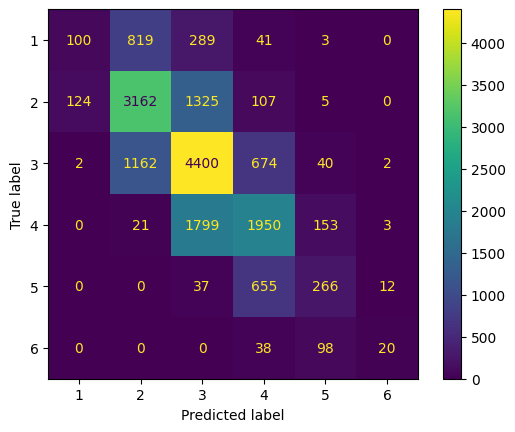

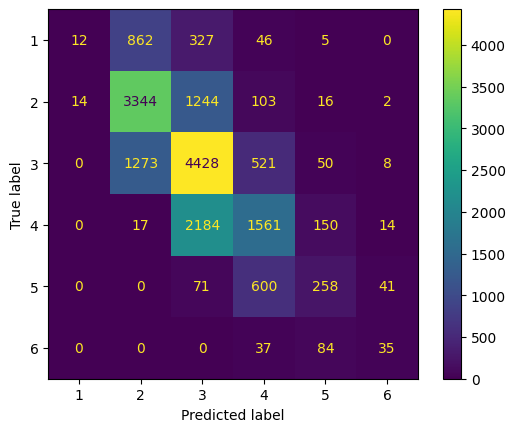

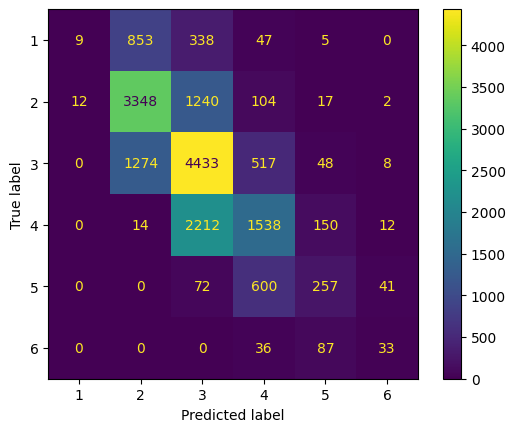

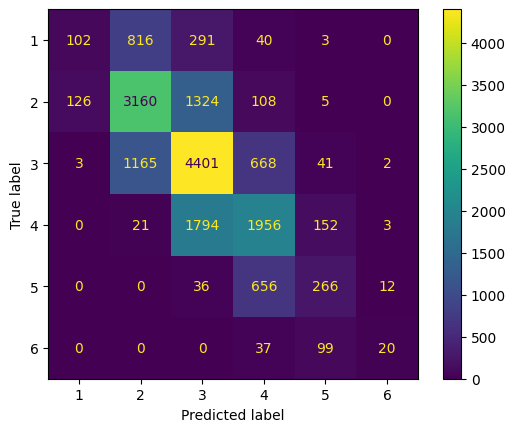

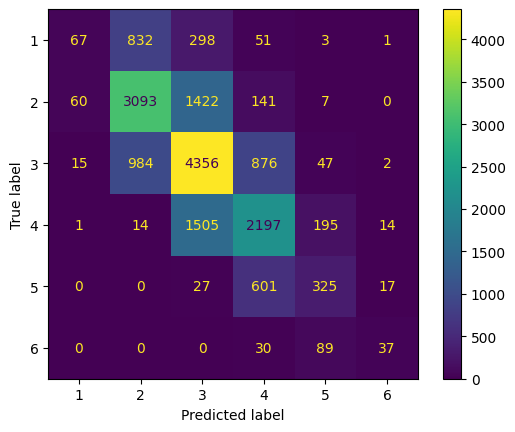

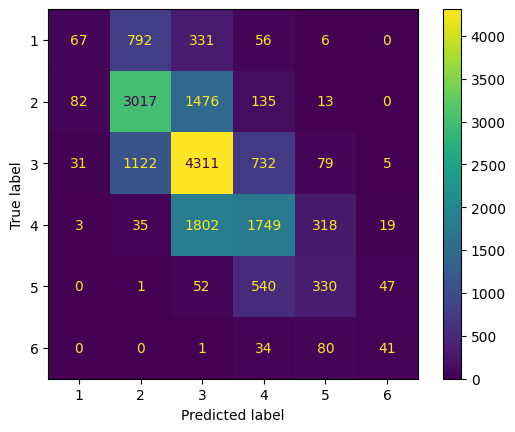

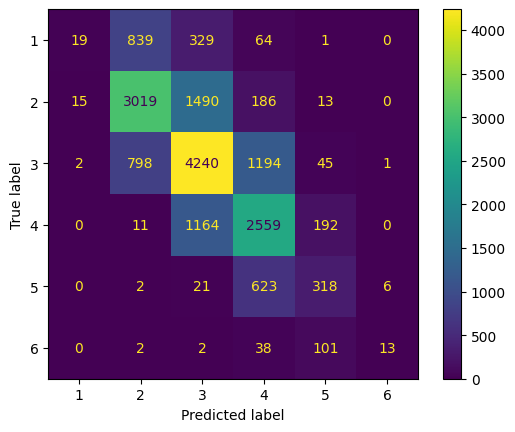

In [56]:
def displayConfusionMatrices(name, preds): 
    for n,p in zip(name, preds):
        p = p.clip(1,6).round() 
        print(f"{n:*^20}")
        ConfusionMatrixDisplay(
            confusion_matrix(train["score"], p, ),
            display_labels = [i for i in range(1, 7)]
        ).plot()
names = ["lr", "en", "lasso_", "ridge", "logistic", "sgd", "svc"]
preds = [lr_preds, en_preds, lasso_preds, ridge_preds, logistic_preds, sgd_preds, svc_preds]

displayConfusionMatrices(names, preds)

In [57]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

PREDS = {"preds": []}


def objective(trial): 
    a = trial.suggest_float("1", 1, 2)
    b = trial.suggest_float("2", 2, 3)
    c = trial.suggest_float("3", 3, 4)
    d = trial.suggest_float("4", 4, 5)
    e = trial.suggest_float("5", 5, 6)

    def cut(x, a=a,b=b,c=c,d=d,e=e): 
        if x<a: return 1
        elif x<b: return 2
        elif x<c: return 3
        elif x<d: return 4
        elif x<e: return 5
        else: return 6

    return cohen_kappa_score(train["score"], list(map(cut, PREDS["preds"])), weights = 'quadratic')

In [58]:
PREDS["preds"] = lr_preds
study = optuna.create_study(direction = "maximize") 
study.optimize(objective, n_trials = 300)

In [59]:
study.best_trial.value

0.7320446781754463

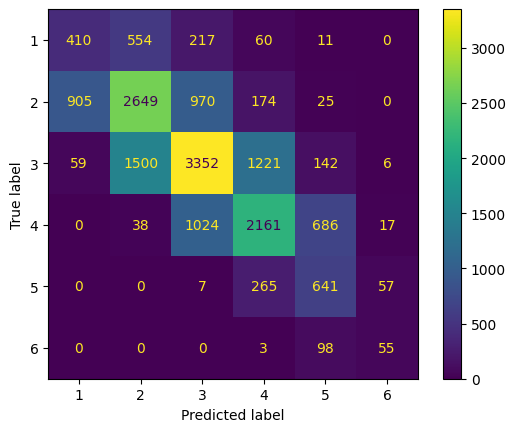

In [60]:
lr_th = study.best_params # lr_threholds

def cut(x, a=lr_th["1"],b=lr_th["2"],c=lr_th["3"],d=lr_th["4"],e=lr_th["5"]): 
        if x<a: return 1
        elif x<b: return 2
        elif x<c: return 3
        elif x<d: return 4
        elif x<e: return 5
        else: return 6


ConfusionMatrixDisplay(
            confusion_matrix(train["score"], list(map(cut, lr_preds)), ),
            display_labels = [i for i in range(1, 7)]
        ).plot()

#### Let's Try Stacking of Logistic with Linear Regression

In [61]:
new = train.join(pd.DataFrame(data = logistic_probs, columns = [f"{i}" for i in range(1, 7)]))

lr_preds2 = np.zeros(len(train))

for tri, tsi in skf.split(X = train, y = train["score"]): 
    lr2 = LinearRegression() 

    lr2.fit(
        X = new.drop("score", axis = 1).loc[tri],
        y = new["score"].loc[tri]
    )

    lr_preds2[tsi] = lr2.predict(
        new.drop("score", axis = 1).loc[tsi])

In [62]:
# Comparing Simple LR and Stacking LR Scores

print(
    cohen_kappa_score(train["score"], lr_preds.clip(1, 6).round(), weights = "quadratic") * 100,
    cohen_kappa_score(train["score"], lr_preds2.clip(1, 6).round(), weights = "quadratic") * 100
)

69.49287498148801 70.01711267762707


In [63]:
n_trials = 400
PREDS["preds"] = lr_preds
study.optimize(objective, n_trials = n_trials)

print("Simple Linear Regression Threshold optimization", study.best_trial.value)

PREDS["preds"] = lr_preds2
study.optimize(objective, n_trials = n_trials)

print("Stacking Linear Regression Threshold optimization", study.best_trial.value)

Simple Linear Regression Threshold optimization 0.7326391746821814
Stacking Linear Regression Threshold optimization 0.7348368730811514


In [64]:
import tensorflow as tf 
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Activation, Dense, GaussianNoise
from tensorflow.keras.models import Model
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [65]:
num_features = len(train.columns)-1
neurons = [num_features, num_features*2, num_features*3, num_features*3, num_features*2]
dropouts = [.1, .15, .2, .2, .15]
epochs = 30

def createMLP(num_features, labels = 1,):
    _input = Input(shape = (num_features, )) 
    x = GaussianNoise(.08, seed = 42)(_input) 
    x = BatchNormalization()(x) 
    
    for i in range(5): 
        x = Dense(neurons[i])(x)
        x = Activation("swish")(x)
        x = BatchNormalization()(x)
        x = Dropout(dropouts[i])(x) 
    
    x = Dense(64)(x) 
    x = Activation("swish")(x)
    output = Dense(labels)(x)  
    
    model = Model(inputs = _input, outputs = output) 
    if labels==1:
        model.compile(
            loss = "mse", 
            optimizer = Adam(learning_rate = .001),
        ) 
    else: 
        model.compile(
            loss = sparse_categorical_crossentropy, 
            optimizer = Adam(learning_rate = .001),
        ) 
    
    return model

In [66]:
labels = 1

def getMLPPredictions(train, labels=1, batch_size = 256):
    num_features = len(train.columns)-1
    mlp_preds = np.zeros(len(train)) 
    
    for idx, (tri, tsi) in enumerate(skf.split(X = train, y = train["score"])): 
    
        ckpt = f"MLP_{idx}.weights.h5"
        
        rlr_cb = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 4, verbose = 0, 
                                min_delta = 1e-4, mode = 'min')
        
        ckp_cb = ModelCheckpoint(ckpt, monitor = 'val_loss', verbose = 0, 
                               save_best_only = True, save_weights_only = True, mode = 'min')
        
        es_cb = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, patience = 6, mode = 'min', 
                           baseline = None, restore_best_weights = True, verbose = 0)
        
        model = createMLP(num_features = num_features)
        
        model.fit(
                x = train.drop("score", axis = 1).loc[tri],
                y = train["score"].loc[tri] + (0 if labels == 1 else -1),
            
            validation_data = (
                train.drop("score", axis = 1).loc[tri],
                train["score"].loc[tri] + (0 if labels == 1 else -1),
            ),
            
            batch_size = batch_size, 
            epochs = epochs, 
            callbacks = [rlr_cb, ckp_cb, es_cb], 
            verbose = 0
        )
    
        if labels == 1:
            mlp_preds[tsi] = model.predict(train.drop("score", axis = 1).loc[tsi]).reshape(-1)
        else: 
            mlp_preds[tsi] = model.predict(train.drop("score", axis = 1).loc[tsi]).argmax(-1).reshape(-1)

    return mlp_preds

mlp_preds = getMLPPredictions(logistic_train)

2026-08-08 06:35:08.450857: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [67]:
mlp_score = cohen_kappa_score(train["score"], mlp_preds.clip(1,6).round(), weights = "quadratic")
mlp_score

np.float64(0.7058027139059124)

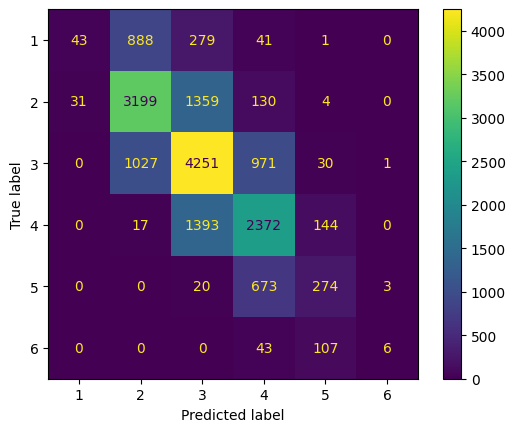

In [68]:
cm = confusion_matrix(train["score"], mlp_preds.clip(1,6).round())
ConfusionMatrixDisplay(cm, display_labels = [i for i in range(1, 7)]).plot()

In [69]:
names = ["lr", "en", "lasso", "ridge", "logistic", "sgd", "svc", "mlp",]
preds = [lr_score, en_score, lasso_score, ridge_score, logistic_score, sgd_score, svc_score, mlp_score,]

Text(0, 0.5, 'QWK Score')

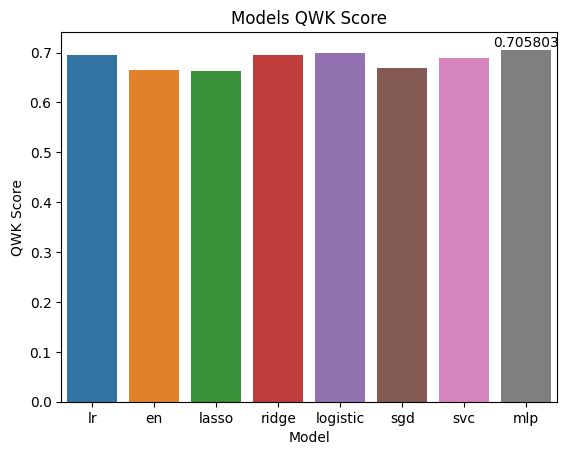

In [70]:
ax = sns.barplot(x = names, y = preds, hue = names)
ax.bar_label(ax.containers[np.argmax(preds)], fontsize=10)
ax.set_title("Models QWK Score")
ax.set_xlabel("Model")
ax.set_ylabel("QWK Score")

#### Testing Stacking of Logistic Regression with Multi Layer Perceptron

In [71]:
for col in range(6):
    logistic_train[f"{col}"] = sc.fit_transform(logistic_probs[:, col].reshape(-1, 1)).reshape(-1) 

In [72]:
mlp2_preds = getMLPPredictions(logistic_train)

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [73]:
mlp2_score = cohen_kappa_score(train["score"], mlp2_preds.clip(1,6).round(), weights = "quadratic")
mlp2_score

np.float64(0.7113901798866191)

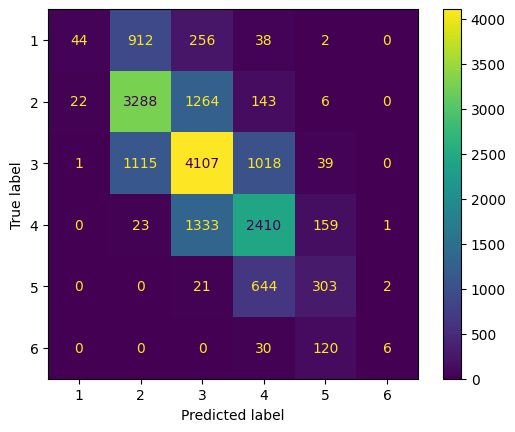

In [74]:
cm = confusion_matrix(train["score"], mlp2_preds.clip(1,6).round()) 
ConfusionMatrixDisplay(cm, display_labels = [f"{i}" for i in range(1, 7)]).plot()

In [75]:
names = ["lr", "en", "lasso", "ridge", "mlp", "mlp2"]
models_score = [lr_score, en_score, lasso_score, ridge_score, mlp_score, mlp2_score]
models_preds = [lr_preds, en_preds, lasso_preds, ridge_preds, mlp_preds, mlp2_preds]
optimized_scores = []
difference = []

In [76]:
for i, preds in enumerate(models_preds):
    PREDS["preds"] = preds
    study = optuna.create_study(direction = "maximize") 
    study.optimize(objective, n_trials = 300)
    optimized_scores.append(study.best_trial.value)
    difference.append(optimized_scores[-1]-models_score[i])

#### Let's see how much increase or decrease in QWK score we get after performing threshold optimization on each model's prediction

Text(0.5, 1.0, 'Delta Change in Score after Threshold Optimization')

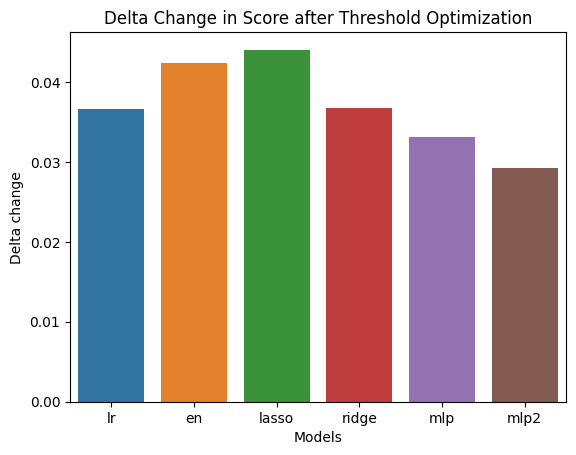

In [84]:
ax = sns.barplot(x = names, y = difference, hue = names)
ax.set_xlabel("Models")
ax.set_ylabel("Delta change")
ax.set_title("Delta Change in Score after Threshold Optimization")

#### Each model is showing improvement in QWK score by atleast 3.7 (~5%)

1. This is the end of this notebook
2. Earlier I engineered some paragraph, sentences, words, errors and spans features with Polars to reduce feature engineering time.
3. The I conducted Hypothesis testing on key features to check for their statistical significance.
4. After that I have created some cluster with KMeans and found out that clusters can't able to split data based on score.
5. DBSCAN and OPTICS for clustering in this dataset is not recommended as they are unable to provide any reasonable clusters.
6. Then I created Linear Models to get some quick predictions.
7. Found out that Linear Regression, Logistic Regression and SVM are strongest predictors.
8. Stacking of Logistic with Linear Regression unable to increase score significantly.
9. Then created Multi Layer Perceptron which is as powerful as linear models.
10. After that implemented threshold optimization for regression models to generate optimized thresholds to split the labels and improved score of all the linear models and MLP.